In [1]:
# Install compatible versions of PyTorch and Triton
!pip install -q -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [2]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset  # <--- Fixes 'Dataset is not defined' error
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4       # Keep small (4) to save GPU memory
IMG_SIZE = 256       # Standard Pix2Pix size
LR = 0.0002          # Learning Rate
EPOCHS = 10          # Suggested: 10-50

# IMPORTANT: Replace this path with YOUR uploaded dataset path!
# It usually looks like: "/kaggle/input/your-dataset-name/maps"
DATA_PATH = "/kaggle/input/datasets/yogadarsa/mapdata/maps" 

# Verify the path exists
if os.path.exists(DATA_PATH):
    print(f"Dataset found at: {DATA_PATH}")
    print("Folders found:", os.listdir(DATA_PATH)) # Should show 'train' and 'val'
else:
    print(f"❌ ERROR: Path not found at {DATA_PATH}")
    print("Please copy the correct path from the 'Data' sidebar on the right.")

print(f"Using Device: {device}")

Dataset found at: /kaggle/input/datasets/yogadarsa/mapdata/maps
Folders found: ['val', 'train']
Using Device: cuda


DataLoaders ready.


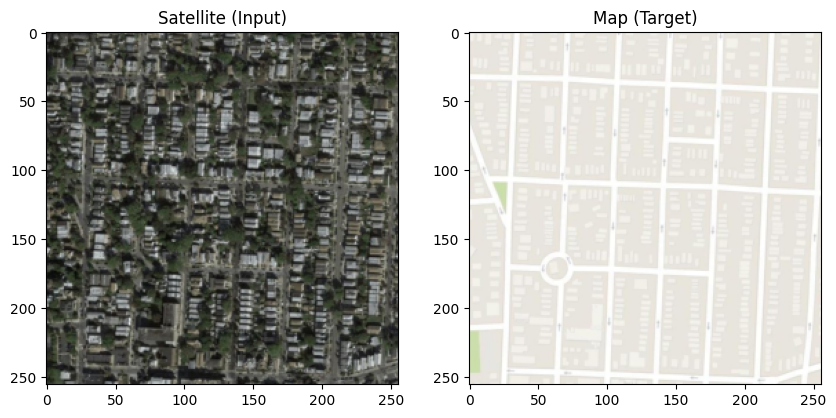

In [3]:
class MapSatelliteDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.files = glob.glob(os.path.join(root_dir, split, "*.jpg"))
        
        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1]
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            img_path = self.files[idx]
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            
            # Split: Left = Satellite, Right = Map
            sat_img = img.crop((0, 0, w//2, h))  
            map_img = img.crop((w//2, 0, w, h)) 
            
            # Transform
            real_A = self.transform(sat_img) # Input: Satellite
            real_B = self.transform(map_img) # Target: Map
            
            return {'A': real_A, 'B': real_B}
        except Exception as e:
            print(f"Skipping bad image: {e}")
            return self.__getitem__((idx + 1) % len(self.files))

# Initialize Loaders
if os.path.exists(DATA_PATH):
    train_ds = MapSatelliteDataset(DATA_PATH, split='train')
    val_ds   = MapSatelliteDataset(DATA_PATH, split='val')

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False)
    
    print("DataLoaders ready.")
    
    # Show a sample
    sample = next(iter(train_loader))
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.imshow(sample['A'][0].permute(1,2,0)*0.5+0.5); plt.title("Satellite (Input)")
    plt.subplot(1,2,2); plt.imshow(sample['B'][0].permute(1,2,0)*0.5+0.5); plt.title("Map (Target)")
    plt.show()
else:
    print("Please fix DATA_PATH in Cell 1 first.")

In [4]:
# --- Generator (U-Net) ---
class UNetDown(nn.Module):
    def __init__(self, in_c, out_c, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize: layers.append(nn.InstanceNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout: layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x): return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_c),
            nn.ReLU(inplace=True)
        ]
        if dropout: layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)
        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)
        return self.final(u7)

# --- Discriminator (PatchGAN) ---
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization: layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False)
        )
    def forward(self, img_A, img_B):
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

In [5]:
# Setup
generator = GeneratorUNet().to(device)
discriminator = Discriminator(in_channels=6).to(device) # Sat + Map = 6 channels
criterion_GAN = nn.MSELoss()
criterion_pixel = nn.L1Loss()
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
lambda_pixel = 100

print("--- Starting Pix2Pix (Supervised) ---")
for epoch in range(EPOCHS):
    for i, batch in enumerate(train_loader):
        real_A = batch['A'].to(device) # Satellite
        real_B = batch['B'].to(device) # Map
        valid = torch.ones((real_A.size(0), 1, 16, 16), device=device)
        fake = torch.zeros((real_A.size(0), 1, 16, 16), device=device)

        # Train G
        optimizer_G.zero_grad()
        fake_B = generator(real_A)
        pred_fake = discriminator(fake_B, real_A)
        loss_GAN = criterion_GAN(pred_fake, valid)
        loss_pixel = criterion_pixel(fake_B, real_B)
        loss_G = loss_GAN + (lambda_pixel * loss_pixel)
        loss_G.backward()
        optimizer_G.step()

        # Train D
        optimizer_D.zero_grad()
        pred_real = discriminator(real_B, real_A)
        loss_real = criterion_GAN(pred_real, valid)
        pred_fake = discriminator(fake_B.detach(), real_A)
        loss_fake = criterion_GAN(pred_fake, fake)
        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

    print(f"[Epoch {epoch+1}/{EPOCHS}] D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

--- Starting Pix2Pix (Supervised) ---
[Epoch 1/10] D Loss: 0.1187 | G Loss: 10.0208
[Epoch 2/10] D Loss: 0.0833 | G Loss: 7.0250
[Epoch 3/10] D Loss: 0.1139 | G Loss: 12.9634
[Epoch 4/10] D Loss: 0.0293 | G Loss: 10.6335
[Epoch 5/10] D Loss: 0.0618 | G Loss: 11.3771
[Epoch 6/10] D Loss: 0.0507 | G Loss: 6.5255
[Epoch 7/10] D Loss: 0.0534 | G Loss: 9.8482
[Epoch 8/10] D Loss: 0.0870 | G Loss: 7.0126
[Epoch 9/10] D Loss: 0.1061 | G Loss: 6.6270
[Epoch 10/10] D Loss: 0.0347 | G Loss: 7.7245


In [8]:
# --- Define CycleGAN-Specific Discriminator ---
class CycleDiscriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization: layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        
        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False)
        )

    def forward(self, img):
        return self.model(img) # No concatenation, just checks the single image

# --- Re-Initialize Models for CycleGAN ---
G_AB = GeneratorUNet().to(device) # Generator: Satellite -> Map
G_BA = GeneratorUNet().to(device) # Generator: Map -> Satellite
D_A = CycleDiscriminator(in_channels=3).to(device) # Checks Satellite Realism
D_B = CycleDiscriminator(in_channels=3).to(device) # Checks Map Realism

# Optimizers & Loss
opt_G = optim.Adam(list(G_AB.parameters()) + list(G_BA.parameters()), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(list(D_A.parameters()) + list(D_B.parameters()), lr=LR, betas=(0.5, 0.999))
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()  # <--- This is the variable name we need

print("--- Starting CycleGAN (Unsupervised) ---")
# Short training for demonstration
for epoch in range(5): 
    for i, batch in enumerate(train_loader):
        real_A = batch['A'].to(device) # Satellite
        real_B = batch['B'].to(device) # Map
        
        # Valid/Fake targets
        valid = torch.ones((real_A.size(0), 1, 16, 16), device=device)
        fake = torch.zeros((real_A.size(0), 1, 16, 16), device=device)

        # ------------------
        #  Train Generators
        # ------------------
        opt_G.zero_grad()
        
        # GAN Loss (Forward & Backward)
        fake_B = G_AB(real_A)
        loss_GAN_AB = criterion_GAN(D_B(fake_B), valid) # D_B checks Map
        
        fake_A = G_BA(real_B)
        loss_GAN_BA = criterion_GAN(D_A(fake_A), valid) # D_A checks Satellite
        
        # Cycle Consistency Loss
        rec_A = G_BA(fake_B) # Sat -> Map -> Sat
        loss_cycle_A = criterion_cycle(rec_A, real_A)
        
        rec_B = G_AB(fake_A) # Map -> Sat -> Map
        # FIXED LINE BELOW:
        loss_cycle_B = criterion_cycle(rec_B, real_B)
        
        # Total Generator Loss
        loss_G = loss_GAN_AB + loss_GAN_BA + (10.0 * (loss_cycle_A + loss_cycle_B))
        loss_G.backward()
        opt_G.step()
        
        # ----------------------
        #  Train Discriminators
        # ----------------------
        opt_D.zero_grad()
        
        # D_A (Checks Satellites)
        loss_real_A = criterion_GAN(D_A(real_A), valid)
        loss_fake_A = criterion_GAN(D_A(fake_A.detach()), fake)
        loss_D_A = (loss_real_A + loss_fake_A) / 2
        
        # D_B (Checks Maps)
        loss_real_B = criterion_GAN(D_B(real_B), valid)
        loss_fake_B = criterion_GAN(D_B(fake_B.detach()), fake)
        loss_D_B = (loss_real_B + loss_fake_B) / 2
        
        loss_D = loss_D_A + loss_D_B
        loss_D.backward()
        opt_D.step()

    print(f"[Cycle Epoch {epoch+1}] G Loss: {loss_G.item():.4f} | D Loss: {loss_D.item():.4f}")

--- Starting CycleGAN (Unsupervised) ---
[Cycle Epoch 1] G Loss: 2.7044 | D Loss: 0.2836
[Cycle Epoch 2] G Loss: 2.8263 | D Loss: 0.1585
[Cycle Epoch 3] G Loss: 2.3954 | D Loss: 0.2427
[Cycle Epoch 4] G Loss: 2.2903 | D Loss: 0.2259
[Cycle Epoch 5] G Loss: 2.8040 | D Loss: 0.1265


--- Final Evaluation ---


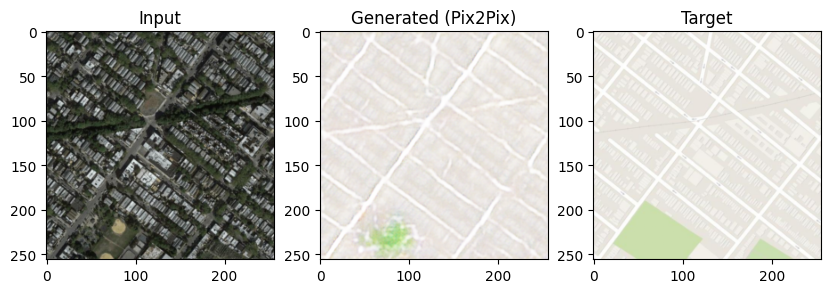

[Pix2Pix] PSNR: 25.67 | SSIM: 0.7665


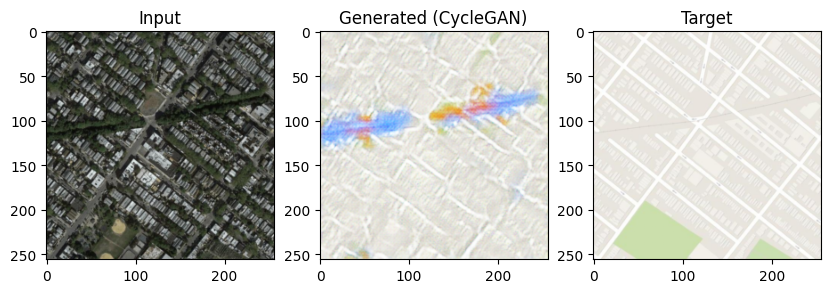

[CycleGAN] PSNR: 20.02 | SSIM: 0.5915


In [11]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def evaluate_model(model, loader, name):
    model.eval()
    total_psnr, total_ssim, count = 0, 0, 0
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            real_A = batch['A'].to(device)
            real_B = batch['B'].to(device)
            fake_B = model(real_A)
            
            # De-normalize
            img_real = np.clip(real_B[0].cpu().permute(1,2,0).numpy() * 0.5 + 0.5, 0, 1)
            img_fake = np.clip(fake_B[0].cpu().permute(1,2,0).numpy() * 0.5 + 0.5, 0, 1)
            
            total_psnr += psnr(img_real, img_fake, data_range=1.0)
            total_ssim += ssim(img_real, img_fake, data_range=1.0, channel_axis=2, win_size=3)
            count += 1
            
            if i == 0:
                plt.figure(figsize=(10,4))
                plt.subplot(1,3,1); plt.imshow(real_A[0].cpu().permute(1,2,0)*0.5+0.5); plt.title("Input")
                plt.subplot(1,3,2); plt.imshow(img_fake); plt.title(f"Generated ({name})")
                plt.subplot(1,3,3); plt.imshow(img_real); plt.title("Target")
                plt.show()

    print(f"[{name}] PSNR: {total_psnr/count:.2f} | SSIM: {total_ssim/count:.4f}")

print("--- Final Evaluation ---")
evaluate_model(generator, val_loader, "Pix2Pix")
evaluate_model(G_AB, val_loader, "CycleGAN")